In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")
Tensor = Float[Array, "..."]

In [27]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 4
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [28]:
def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
bases = [basis]*d_lift

In [29]:
from ctt.model import _eval_bases

def _eval_tensor(tensor: Tensor, x: Float[Array, "d"]) -> Float[Array, "d"]:
    features = _eval_bases(bases, x)
    y = tensor # (d, m, ..., m)
    for i in range(len(features)):
        y = jnp.einsum("di...,i->d...", y, features[i])
    return y

def _eval_ct(tensors: list[Tensor], x: Float[Array, "d"]) -> Float[Array, "d_o"]:
    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tensors])
        return val + _eval_tensor(control, val)

    x = lift(x)
    val = jax.lax.fori_loop(0, len(tensors), _body_fn, x)
    val = retraction(val)
    return val

In [30]:
key, sample_key = random.split(key)
Sigma = random.normal(key=sample_key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "bivariate"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.mean((x[::2] + x[1::2]) ** 2)
    return jnp.atleast_1d(val)

In [32]:
key, train_key, val_key = random.split(key, 3)

domain = (-1., 1.)
N_train = 1_000_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2

In [33]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [34]:
import optax

@jax.jit
def compute_loss(tensors: list[Tensor],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"]) -> float:
    y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    return 0.5*loss

@jax.jit
def grad_loss(y_hat: Float[Array, "B d_o"], y: Float[Array, "B d_o"]) -> Float[Array, "B d_o"]:
    # return y_hat - y
    return (y_hat - y) / y_hat.shape[0]

In [36]:
import jax.flatten_util
import operator
import lineax
from functools import partial

def natural_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             optimizer: optax.GradientTransformation,
                             params: list[Tensor],
                             opt_steps: int,
                             training_key: PRNGKeyArray,
                             batch_size: int = 64,
                             backtracking: bool = False,
                             damping_coeff: float = None) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    def tree_mvp_dampen(mvp, lmbda=0.1):
        dampen_fcn = lambda mvp_, v_: mvp_ + lmbda * v_
        damp_mvp = lambda v: jax.tree.map(dampen_fcn, mvp(v), v)
        return damp_mvp

    def _natural_grad(tensors: list[Tensor],
                      x: Float[Array, "B d"],
                      grads: list[Tensor],
                      y: Float[Array, "B d_o"]) -> list[Tensor]:
        # f = lambda w: jax.vmap(_eval_ct, in_axes=(None,0))(w, x).ravel() / jnp.sqrt(x.shape[0])
        # fvp = lambda v: jax.vjp(f, tensors)[1](jax.jvp(f, (tensors,), (v,))[1])[0]
        # # fvp = tree_mvp_dampen(fvp, lmbda=1e-4)
        # ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grads, maxiter=40, tol=1e-10)
        # # op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grads), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
        # # solution = lineax.linear_solve(op, grads, solver=lineax.AutoLinearSolver(well_posed=True))
        # # ngrad = solution.value
        # # r = jax.tree.map(operator.sub, grads, fvp(ngrad))
        # # r_norm = sum(jax.tree.leaves(jax.tree.map(jnp.vdot, r, r)))
        # # jax.debug.print("Residual: {r}", r=jnp.sqrt(r_norm))
        # return ngrad

        # solving the normal equation G @ dir = grad
        def _block_projection(grad: Tensor, k: int) -> Tensor:
            tt = tensors[k]
            def _f(w: Tensor, *args: None) -> Float[Array, "N"]:
                params = tensors[:k] + [w] + tensors[k+1:]
                return jax.vmap(_eval_ct, in_axes=(None, 0))(params, x).ravel() / jnp.sqrt(x.shape[0])
            fvp = lambda v: jax.vjp(_f, tt)[1](jax.jvp(_f, (tt,), (v,))[1])[0]
            if damping_coeff is not None:
                fvp = tree_mvp_dampen(fvp, lmbda=damping_coeff)
            ngrad, _ = jax.scipy.sparse.linalg.cg(fvp, grad, maxiter=40, tol=1e-10)
            # op = lineax.FunctionLinearOperator(fvp, jax.eval_shape(lambda: grad), tags=[lineax.symmetric_tag, lineax.positive_semidefinite_tag])
            # solution = lineax.linear_solve(op, grad, solver=lineax.AutoLinearSolver(well_posed=True))
            # ngrad = solution.value
            return ngrad
        
        # solving the least-squares problem ||du/dtheta_k @ dir - grad L||
        # y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
        # grad_losses = grad_loss(y_pred, y)
        # def _block_projection(grad: Tensor, k: int) -> Tensor:
        #     tensor = tensors[k]
        #     def _f(w: Tensor, *args: None) -> Float[Array, "B d_o"]:
        #         params = tensors[:k] + [w] + tensors[k+1:]
        #         return jax.vmap(_eval_ct, in_axes=(None, 0))(params, x)
            
        #     J = jax.jacfwd(_f)(tensor)
        #     J = jnp.reshape(J, (J.shape[0]*J.shape[1],-1)) # (B*d_o, n_params)
        #     ngrad, resid, _, _ = jnp.linalg.lstsq(J, grad_losses.ravel(), rcond=1e-5)
        #     ngrad = jnp.reshape(ngrad, tensor.shape)
        #     return ngrad
        
        ngrads = [_block_projection(grads[k], k) for k in range(len(tensors))]
        return ngrads

    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        ngrad = _natural_grad(tensors, x, grads, y)
        if backtracking:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors, value=loss, grad=ngrad, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    optimizer: optax.GradientTransformation,
                    params: list[Tensor],
                    opt_steps: int,
                    training_key: PRNGKeyArray,
                    batch_size: int = 64,
                    backtracking: bool = False) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []
    
    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        if backtracking:
            updates, opt_state = optimizer.update(grads, opt_state, tensors, value=loss, grad=grads, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(grads, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [37]:
key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    0.01*random.normal(key=control_key, shape=(d_lift,) + (n_features,)*d_lift)
    for control_key in control_keys
]
zero_init_controls = [
    jnp.zeros((d_lift,) + (n_features,)*d_lift)
    for _ in range(num_steps)
]
# init_controls = list(map(left_orth, init_controls))
print(list(map(jnp.linalg.norm, init_controls)))

[Array(0.08770601, dtype=float64), Array(0.07408312, dtype=float64)]


In [38]:
optimizer = optax.chain(
    optax.sgd(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="one")
)

params_ng, (train_losses_ng, val_losses_ng), learning_rates_ng = natural_gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=64,
                                                                              backtracking=True,
                                                                              damping_coeff=1e-4)

Iter 0 | Loss: 2.339e-01 | Val loss: 7.377e-02
Iter 5 | Loss: 2.309e-03 | Val loss: 9.633e-04
Iter 10 | Loss: 2.859e-04 | Val loss: 4.132e-04
Iter 15 | Loss: 7.132e-05 | Val loss: 7.652e-05
Iter 20 | Loss: 2.575e-04 | Val loss: 4.142e-05
Iter 25 | Loss: 8.690e-06 | Val loss: 1.828e-05
Iter 30 | Loss: 4.121e-05 | Val loss: 1.125e-05
Iter 35 | Loss: 2.999e-05 | Val loss: 9.127e-06
Iter 40 | Loss: 8.215e-06 | Val loss: 5.895e-06
Iter 45 | Loss: 8.014e-06 | Val loss: 3.612e-06
Iter 50 | Loss: 2.140e-06 | Val loss: 2.720e-06
Iter 55 | Loss: 1.515e-06 | Val loss: 2.119e-06
Iter 60 | Loss: 1.544e-06 | Val loss: 1.456e-06
Iter 65 | Loss: 1.180e-06 | Val loss: 2.153e-06
Iter 70 | Loss: 1.041e-06 | Val loss: 1.220e-06
Iter 75 | Loss: 4.478e-07 | Val loss: 6.634e-07
Iter 80 | Loss: 2.103e-07 | Val loss: 1.150e-06
Iter 85 | Loss: 2.927e-07 | Val loss: 2.851e-07
Iter 90 | Loss: 1.665e-07 | Val loss: 4.328e-07
Iter 95 | Loss: 2.073e-07 | Val loss: 1.662e-07
Iter 100 | Loss: 1.321e-07 | Val loss: 2.2

In [39]:
optimizer = optax.chain(
    optax.adam(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="keep")
)

params_gd, (train_losses_gd, val_losses_gd), learning_rates_gd = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=64,
                                                                              backtracking=True)

Iter 0 | Loss: 2.339e-01 | Val loss: 2.382e-01
Iter 5 | Loss: 1.731e-01 | Val loss: 2.184e-01
Iter 10 | Loss: 1.825e-01 | Val loss: 1.052e-01
Iter 15 | Loss: 7.050e-02 | Val loss: 6.078e-02
Iter 20 | Loss: 5.217e-02 | Val loss: 4.975e-02
Iter 25 | Loss: 4.631e-02 | Val loss: 4.148e-02
Iter 30 | Loss: 5.341e-02 | Val loss: 3.783e-02
Iter 35 | Loss: 3.176e-02 | Val loss: 2.251e-02
Iter 40 | Loss: 3.201e-02 | Val loss: 2.075e-02
Iter 45 | Loss: 2.355e-02 | Val loss: 1.923e-02
Iter 50 | Loss: 2.105e-02 | Val loss: 1.744e-02
Iter 55 | Loss: 1.262e-02 | Val loss: 1.692e-02
Iter 60 | Loss: 1.272e-02 | Val loss: 1.720e-02
Iter 65 | Loss: 1.337e-02 | Val loss: 1.461e-02
Iter 70 | Loss: 1.372e-02 | Val loss: 1.438e-02
Iter 75 | Loss: 1.400e-02 | Val loss: 1.271e-02
Iter 80 | Loss: 1.178e-02 | Val loss: 1.241e-02
Iter 85 | Loss: 1.079e-02 | Val loss: 1.193e-02
Iter 90 | Loss: 1.582e-02 | Val loss: 1.184e-02
Iter 95 | Loss: 1.284e-02 | Val loss: 1.130e-02
Iter 100 | Loss: 1.273e-02 | Val loss: 1.0

Text(0, 0.5, 'Learning rate')

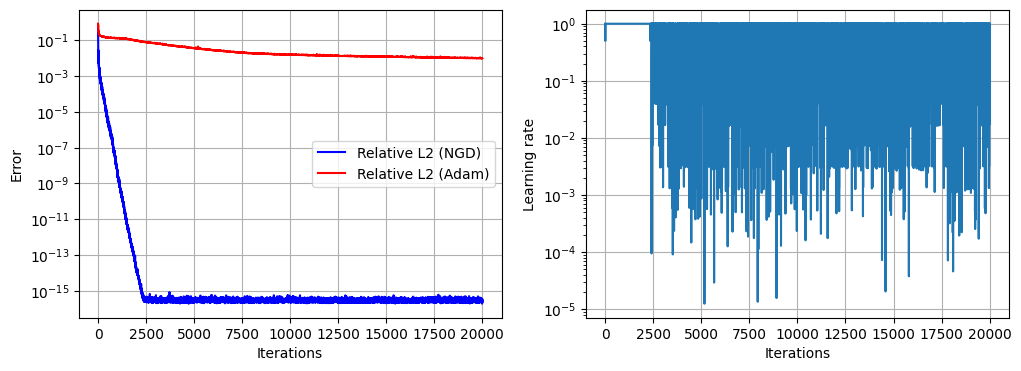

In [40]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses_ng = jnp.asarray(val_losses_ng)
val_losses_gd = jnp.asarray(val_losses_gd)

axes[0].semilogy(jnp.arange(len(val_losses_ng)), jnp.sqrt(val_losses_ng/y_val_norm), label="Relative L2 (NGD)", color="blue")
axes[0].semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (Adam)", color="red")

axes[0].grid()
axes[0].legend()
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Error")

# plot learning rates
axes[1].semilogy(learning_rates_ng)
axes[1].grid()
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Learning rate")